# **MNIST-Digit-Recognition**




In [ ]:
!pip install streamlit
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 43.3 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import streamlit as st
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps
import numpy as np
from tensorflow import keras

MNIST handwritten digits dataset is a classic collection of 70,000 handwritten digit images (0–9), each 28×28 pixels in grayscale, allowing us to practice preprocessing, model building, and evaluating neural networks on real image data without needing complicated data cleaning.

## **Load the dataset**

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


Visualizing the samples

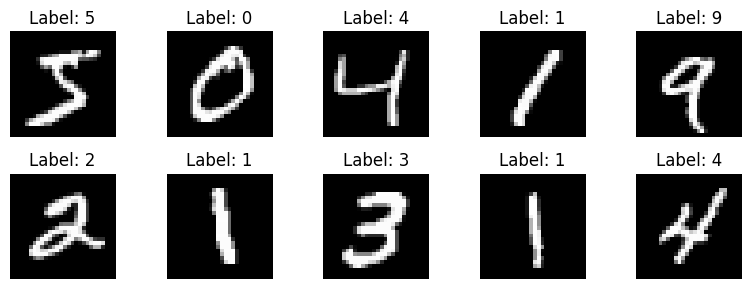

In [ ]:
plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## **Preprocessing**

Images are made up of pixel values, and models perform best when these values are scaled to consistent ranges and arranged in a format the model can understand. Preprocessing ensures that the data is clean, uniform, and ready for efficient training.
In the MNIST dataset, each image is a handwritten digit stored as a 28×28 grayscale image. Before feeding these images into a neural network, we perform two key preprocessing operations: normalizing the pixel values and flattening the image

**Normalize Pixel Values**

Raw pixel values range from 0 to 255.
By dividing every pixel by 255.0, we scale the data to a range between 0 and 1, which helps the neural network train faster and more reliably.

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

visualizing the effect of normalization

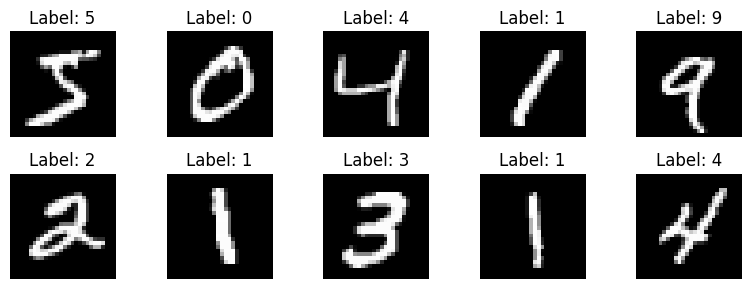

In [ ]:
plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

The results show normalization changes numerical values, not the visual appearance of the image. The network benefits from scaled inputs, but humans won't notice any difference in the displayed image.

**Flatten the Image**

Neural networks that use fully connected (Dense) layers expect each input example to be a 1-dimensional vector.
Since each MNIST image is 28×28, we reshape it into a vector of 784 values (28×28 = 784).

In [ ]:
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

print("Normalized + flattened training shape:", x_train.shape)
print("Normalized + flattened test shape:", x_test.shape)

Normalized + flattened training shape: (60000, 784)
Normalized + flattened test shape: (10000, 784)


## **Building and Experimenting With Neural Network Models**

Creating 3 different models with some meaningful modification, for each, the following will be done:

1. Define the architecture  
2. Train the model (use the same number of epochs for fairness)  
3. Evaluate the model using appropriate evaluation measures on the test set  

the best performing model will be saved as:
```python
model.save("best_model.h5")
```

In [ ]:
#model1, simple model with one layer only using sigmoid activation ftn
model1=keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation='sigmoid')
])
model1.compile(
    optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']
    )
history1 = model1.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=1)
test_loss1, test_acc1 = model1.evaluate(x_test, y_test, verbose=0)
print(f"\nModel 1 Test Accuracy: {test_acc1:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8028 - loss: 0.7494 - val_accuracy: 0.9272 - val_loss: 0.2698
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9099 - loss: 0.3226 - val_accuracy: 0.9317 - val_loss: 0.2430
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9180 - loss: 0.2926 - val_accuracy: 0.9363 - val_loss: 0.2373
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9220 - loss: 0.2783 - val_accuracy: 0.9340 - val_loss: 0.2321
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9240 - loss: 0.2736 - val_accuracy: 0.9367 - val_loss: 0.2302
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9255 - loss: 0.2668 - val_accuracy: 0.9392 - val_loss: 0.2275
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9271 - loss: 0.2670 - val_accuracy: 0.9387 - val_loss: 0.2240
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9268 - loss: 0.2584 - 

In [ ]:
model1.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9163 - loss: 0.3029


[0.26561209559440613, 0.926800012588501]

In [ ]:
#model2 more neurons added, activation ftn change, one more layer
model2= keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(10, activation='softmax')#converts outputs to probabilites
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=1)
test_loss2, test_acc2 = model2.evaluate(x_test, y_test, verbose=0)
print(f"\nModel 2 Test Accuracy: {test_acc2:.4f}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8740 - loss: 0.4394 - val_accuracy: 0.9640 - val_loss: 0.1253
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9631 - loss: 0.1243 - val_accuracy: 0.9727 - val_loss: 0.0951
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9745 - loss: 0.0864 - val_accuracy: 0.9730 - val_loss: 0.0894
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0629 - val_accuracy: 0.9755 - val_loss: 0.0807
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9860 - loss: 0.0453 - val_accuracy: 0.9763 - val_loss: 0.0785
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9886 - loss: 0.0354 - val_accuracy: 0.9783 - val_loss: 0.0742
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9917 - loss: 0.0282 - val_accuracy: 0.9775 - val_loss: 0.0792
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9933 - loss: 0.0232 - 

In [ ]:
model2.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9766 - loss: 0.0968


[0.0867924764752388, 0.9776999950408936]

In [ ]:
#model3 more layers with diff number of neurons, optimizer changed from adam to sgd
model3 = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model3.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=1)
test_loss3, test_acc3 = model3.evaluate(x_test, y_test, verbose=0)
print(f"\nModel 3 Test Accuracy: {test_acc3:.4f}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6961 - loss: 1.1002 - val_accuracy: 0.9240 - val_loss: 0.2690
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9166 - loss: 0.2911 - val_accuracy: 0.9352 - val_loss: 0.2280
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9359 - loss: 0.2185 - val_accuracy: 0.9555 - val_loss: 0.1639
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9462 - loss: 0.1812 - val_accuracy: 0.9627 - val_loss: 0.1371
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9541 - loss: 0.1527 - val_accuracy: 0.9682 - val_loss: 0.1231
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9612 - loss: 0.1301 - val_accuracy: 0.9672 - val_loss: 0.1188
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9675 - loss: 0.1129 - val_accuracy: 0.9703 - val_loss: 0.1053
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9697 - loss: 0.1008 - 

In [ ]:
model3.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9676 - loss: 0.1061


[0.09276740998029709, 0.9711999893188477]

In [ ]:
#model4 changed activation to leaky relu which prevents dead neurons problem,also did batch normalization added dropout to prevent overftting and used a lower learning rate
model4 = keras.Sequential([
    keras.layers.Dense(256, input_shape=(784,)),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(alpha=0.1),
    keras.layers.Dense(128),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(alpha=0.1),
    keras.layers.Dense(10, activation='softmax')
])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model4.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history4 = model4.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=1)
test_loss4, test_acc4 = model4.evaluate(x_test, y_test, verbose=0)
print(f"\nModel 4 Test Accuracy: {test_acc4:.4f}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8817 - loss: 0.4008 - val_accuracy: 0.9725 - val_loss: 0.1023
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9650 - loss: 0.1181 - val_accuracy: 0.9757 - val_loss: 0.0838
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9749 - loss: 0.0820 - val_accuracy: 0.9782 - val_loss: 0.0751
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9798 - loss: 0.0631 - val_accuracy: 0.9795 - val_loss: 0.0757
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9835 - loss: 0.0504 - val_accuracy: 0.9827 - val_loss: 0.0680
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9857 - loss: 0.0440 - val_accuracy: 0.9810 - val_loss: 0.0665
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9888 - loss: 0.0346 - val_accuracy: 0.9803 - val_loss: 0.0752
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9889 - loss: 0.0341 -

In [ ]:
model4.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9787 - loss: 0.0711


[0.061442743986845016, 0.9817000031471252]

In [ ]:
accuracies = [test_acc1, test_acc2, test_acc3, test_acc4]
best_index = accuracies.index(max(accuracies))
best_model = [model1, model2, model3, model4][best_index]

print(f"\nBest model is Model {best_index + 1} with accuracy {accuracies[best_index]:.4f}")

best_model.save("best_model.h5")


Best model is Model 4 with accuracy 0.9817


## **Integrating The Model Into a Streamlit Application**

The best-performing MNIST model will be deployed in a simple web application using Streamlit.
The Streamlit app will:
1. Load the saved model.  
2. Allow the user to upload a small handwritten image.  
3. Preprocess the input (resize to 28×28, grayscale, normalize, flatten if necessary).  
4. Predict the digit using your trained model.  
5. Display the predicted number on the web page.  

In [ ]:
%%writefile app.py
import streamlit as st
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
model = load_model("best_model.h5")

st.title("MNIST Digit Predictor")
st.write("Upload image of a handwritten digit 0-9")
uploaded_file = st.file_uploader("Upload image", type=["png", "jpg", "jpeg"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption="Uploaded image", width=150)
    image = image.convert("L")
    image = image.resize((28, 28))
    img_array = np.array(image)
    img_array = 255 - img_array
    img_array = img_array / 255.0
    img_array = img_array.reshape(1, 28 * 28)

    st.image(image, caption="Uploaded image", use_column_width=True)
    prediction = model.predict(img_array)
    digit = np.argmax(prediction)

    st.write("Predicted digit:", digit)

Overwriting app.py
